In this notebook we want to show this narrative:
- Try 3-5 different pre-trained models initially using the same architecture and just changing the model
- Compare results and select the best performing one
- Fine-tune a smaller version of the model and compare performance a bigger version without fine-tuning

# Pre-trained models

## 0. Imports and GPU config

In [1]:
import sys
sys.path.append('../src')

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import keras
from keras import layers

from utils import plot_model_history

2026-04-22 00:04:01.681331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776812641.704934  186407 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776812641.713809  186407 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776812641.806736  186407 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776812641.806769  186407 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776812641.806772  186407 computation_placer.cc:177] computation placer alr

Check if our GPU is detected

In [2]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Configure memory limit to take advantage of all of our VRAM

In [3]:
for gpu in gpus:
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(3.8*1024))]
    )

## 1. Data import

In [4]:
image_size = (512, 512) # use original image size
input_shape = image_size + (3,)
batch_size = 4 # use a smaller value since we are using a bigger resolution
n_classes = 23

train_ds = keras.utils.image_dataset_from_directory(
    "../Data/Train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    "../Data/Validation",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_ds = keras.utils.image_dataset_from_directory(
    "../Data/Test",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 9329 files belonging to 23 classes.


I0000 00:00:1776812647.474743  186407 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3891 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 1999 files belonging to 23 classes.
Found 2000 files belonging to 23 classes.


## 2. VGG16

<img src="../images/vgg16.png" width="50%"/>

VGG16 was developed in Oxford University and it is a simple but big model in terms of parameters. It just stacks 3x3 convolutional layers followed by max pooling layers, in four blocks and ends with three fully connected layers. It has a big parameter count because of the big fully connected layers at the end and the flatten layer, so it is not very parameter efficient.

check if it valid to pass our own image size, or if it is better to use the default values from each model

check if it is better to pass the correct number of classes to the base model or not

In [ ]:
vgg16_base_model = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23
)

vgg16_base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=input_shape)

# try resizing the image to the default image size of VGG16
# x = layers.Resizing(224, 224)(inputs)

# try augmentation
x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

# apply VGG16 preprocessing
# The images are converted from RGB to BGR, then each color channel 
# is zero-centered with respect to the ImageNet dataset, without scaling.
x = keras.applications.vgg16.preprocess_input(x)

x = vgg16_base_model(x, training=False)

# x = layers.Flatten()(x)
# use Flatten like VGG16 originally
# we experimented also with GlobalAveragePooling to reduce the number of trainable params
x = layers.GlobalAveragePooling2D()(x)

# try dropout
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(n_classes, activation="softmax")(x)


vgg16_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="vgg16_pre_trained")

In [8]:
vgg16_pre_trained_model.summary()

Model: "vgg16_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_moder… │ (None, 512, 512,  │          0 │ input_layer_1[0]… │
│ (Pipeline)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512, 512)  │          0 │ augmentation_mod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 512, 512,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 16, 16,    │ 14,714,688 │ add[0][0]         │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 131072)    │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 131072)    │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 23)        │  3,014,679 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,729,367 (67.63 MB)

 Trainable params: 3,014,679 (11.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

using image size (512, 512), 0.2 dropout, moderate noise augmentation, global avg pooling

In [53]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [ ]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 612s 260ms/step - categorical_accuracy: 0.4586 - f1_score: 0.4210 - loss: 2.1895 - val_categorical_accuracy: 0.6392 - val_f1_score: 0.6177 - val_loss: 1.3433
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 611s 262ms/step - categorical_accuracy: 0.6266 - f1_score: 0.5977 - loss: 1.3594 - val_categorical_accuracy: 0.6962 - val_f1_score: 0.6715 - val_loss: 1.1442
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 615s 263ms/step - categorical_accuracy: 0.6544 - f1_score: 0.6320 - loss: 1.2418 - val_categorical_accuracy: 0.7031 - val_f1_score: 0.6797 - val_loss: 1.1420
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 603s 258ms/step - categorical_accuracy: 0.6809 - f1_score: 0.6592 - loss: 1.1824 - val_categorical_accuracy: 0.6932 - val_f1_score: 0.6743 - val_loss: 1.2086


: 

### old attempts

using image size (512, 512), 0.5 dropout, moderate noise augmentation, flatten

In [9]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [10]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


I0000 00:00:1776796732.921888  112941 cuda_dnn.cc:529] Loaded cuDNN version 91002


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 610s 259ms/step - categorical_accuracy: 0.4885 - f1_score: 0.4601 - loss: 83.9884 - val_categorical_accuracy: 0.5988 - val_f1_score: 0.5580 - val_loss: 99.5810
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 607s 260ms/step - categorical_accuracy: 0.6790 - f1_score: 0.6603 - loss: 69.1313 - val_categorical_accuracy: 0.6258 - val_f1_score: 0.5817 - val_loss: 114.0066
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 608s 260ms/step - categorical_accuracy: 0.7391 - f1_score: 0.7265 - loss: 60.6075 - val_categorical_accuracy: 0.6588 - val_f1_score: 0.6317 - val_loss: 115.3173
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 613s 263ms/step - categorical_accuracy: 0.7814 - f1_score: 0.7689 - loss: 56.0749 - val_categorical_accuracy: 0.6663 - val_f1_score: 0.6348 - val_loss: 130.1535
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 612s 262ms/step - categorical_accuracy: 0.8143 - f1_score: 0.8049 - loss: 47.2091 - val_categorical_accuracy: 0.6723 - val_f1_score: 0.6445 - val_loss: 148.55

using image size (224, 224), 0.2 dropout, moderate noise augmentation, global avg pooling

In [49]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [50]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.3870 - f1_score: 0.3576 - loss: 3.1570 - val_categorical_accuracy: 0.5537 - val_f1_score: 0.5157 - val_loss: 2.4349
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 153s 65ms/step - categorical_accuracy: 0.5425 - f1_score: 0.5197 - loss: 1.9773 - val_categorical_accuracy: 0.5957 - val_f1_score: 0.5693 - val_loss: 1.9901
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 155s 66ms/step - categorical_accuracy: 0.5749 - f1_score: 0.5526 - loss: 1.8195 - val_categorical_accuracy: 0.5847 - val_f1_score: 0.5627 - val_loss: 2.2339


using image size (224, 224), 0.5 dropout, moderate noise augmentation, global avg pooling

In [45]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [46]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 148s 63ms/step - categorical_accuracy: 0.3025 - f1_score: 0.2749 - loss: 4.5527 - val_categorical_accuracy: 0.5302 - val_f1_score: 0.4874 - val_loss: 2.4021
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.4324 - f1_score: 0.4066 - loss: 2.8519 - val_categorical_accuracy: 0.5652 - val_f1_score: 0.5311 - val_loss: 2.2426
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.4597 - f1_score: 0.4358 - loss: 2.5847 - val_categorical_accuracy: 0.5792 - val_f1_score: 0.5504 - val_loss: 2.1201
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.4662 - f1_score: 0.4431 - loss: 2.5733 - val_categorical_accuracy: 0.5777 - val_f1_score: 0.5443 - val_loss: 2.1205


using image size (224, 224), 0.5 dropout, moderate noise augmentation, flatten with one more dense layer

In [41]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [42]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 162s 65ms/step - categorical_accuracy: 0.3903 - f1_score: 0.3651 - loss: 48.6879 - val_categorical_accuracy: 0.4873 - val_f1_score: 0.4371 - val_loss: 17.0910
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 156s 67ms/step - categorical_accuracy: 0.4913 - f1_score: 0.4657 - loss: 10.9770 - val_categorical_accuracy: 0.4643 - val_f1_score: 0.4081 - val_loss: 14.8993


using image size (224, 224), 0.5 dropout, moderate noise augmentation, flatten

In [37]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [38]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 64ms/step - categorical_accuracy: 0.4225 - f1_score: 0.3980 - loss: 41.9377 - val_categorical_accuracy: 0.5557 - val_f1_score: 0.5295 - val_loss: 47.6201
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 64ms/step - categorical_accuracy: 0.5771 - f1_score: 0.5579 - loss: 40.3491 - val_categorical_accuracy: 0.5907 - val_f1_score: 0.5649 - val_loss: 57.1677
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.6381 - f1_score: 0.6227 - loss: 37.9426 - val_categorical_accuracy: 0.6097 - val_f1_score: 0.5829 - val_loss: 67.4209
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.6770 - f1_score: 0.6637 - loss: 35.4321 - val_categorical_accuracy: 0.5892 - val_f1_score: 0.5622 - val_loss: 79.4678


using image size (224, 224), 0.2 dropout, moderate noise augmentation, flatten

In [33]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [34]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


2335/2335 ━━━━━━━━━━━━━━━━━━━━ 148s 62ms/step - categorical_accuracy: 0.4488 - f1_score: 0.4244 - loss: 39.8330 - val_categorical_accuracy: 0.5452 - val_f1_score: 0.5148 - val_loss: 57.2753
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.6314 - f1_score: 0.6170 - loss: 31.5781 - val_categorical_accuracy: 0.5672 - val_f1_score: 0.5417 - val_loss: 65.6575
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.7030 - f1_score: 0.6922 - loss: 27.5114 - val_categorical_accuracy: 0.5842 - val_f1_score: 0.5513 - val_loss: 73.5633
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 152s 65ms/step - categorical_accuracy: 0.7506 - f1_score: 0.7434 - loss: 23.8692 - val_categorical_accuracy: 0.6007 - val_f1_score: 0.5734 - val_loss: 72.8336
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 153s 66ms/step - categorical_accuracy: 0.7700 - f1_score: 0.7646 - loss: 22.5152 - val_categorical_accuracy: 0.5942 - val_f1_score: 0.5717 - val_loss: 83.0894


using image size (224, 224), no dropout, moderate noise augmentation, flatten

In [29]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [30]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 152s 64ms/step - categorical_accuracy: 0.4625 - f1_score: 0.4387 - loss: 39.5173 - val_categorical_accuracy: 0.5417 - val_f1_score: 0.5059 - val_loss: 57.4202
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.6538 - f1_score: 0.6389 - loss: 30.3802 - val_categorical_accuracy: 0.5587 - val_f1_score: 0.5355 - val_loss: 68.8677
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.7290 - f1_score: 0.7187 - loss: 24.9901 - val_categorical_accuracy: 0.5822 - val_f1_score: 0.5537 - val_loss: 75.8659
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.7774 - f1_score: 0.7703 - loss: 20.6918 - val_categorical_accuracy: 0.5877 - val_f1_score: 0.5616 - val_loss: 89.3586
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.7962 - f1_score: 0.7906 - loss: 20.0061 - val_categorical_accuracy: 0.5987 - val_f1_score: 0.5726 - val_loss: 90.

using image size (224, 224), 0.2 dropout, no augmentation, flatten

In [81]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [82]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 133s 56ms/step - categorical_accuracy: 0.4941 - f1_score: 0.4688 - loss: 45.2641 - val_categorical_accuracy: 0.5872 - val_f1_score: 0.5529 - val_loss: 48.4226
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 126s 54ms/step - categorical_accuracy: 0.8266 - f1_score: 0.8249 - loss: 13.0871 - val_categorical_accuracy: 0.5977 - val_f1_score: 0.5599 - val_loss: 57.9407
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 127s 54ms/step - categorical_accuracy: 0.8815 - f1_score: 0.8770 - loss: 8.7916 - val_categorical_accuracy: 0.6142 - val_f1_score: 0.5829 - val_loss: 67.2706
Epoch 4/10
2020/2335 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - categorical_accuracy: 0.9037 - f1_score: 0.8991 - loss: 8.0886

KeyboardInterrupt: 

using image size (224, 224), no dropout, no augmentation, flatten

lower parameters count compared to the bigger image size, because of flatten

In [56]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [57]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 140s 56ms/step - categorical_accuracy: 0.5046 - f1_score: 0.4815 - loss: 47.2036 - val_categorical_accuracy: 0.5947 - val_f1_score: 0.5577 - val_loss: 51.1798
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 125s 54ms/step - categorical_accuracy: 0.8529 - f1_score: 0.8482 - loss: 11.5556 - val_categorical_accuracy: 0.5912 - val_f1_score: 0.5636 - val_loss: 67.0623
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 126s 54ms/step - categorical_accuracy: 0.8923 - f1_score: 0.8919 - loss: 8.3775 - val_categorical_accuracy: 0.5892 - val_f1_score: 0.5677 - val_loss: 84.4971
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 126s 54ms/step - categorical_accuracy: 0.9188 - f1_score: 0.9143 - loss: 6.8672 - val_categorical_accuracy: 0.6202 - val_f1_score: 0.5880 - val_loss: 83.9951
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 127s 54ms/step - categorical_accuracy: 0.9331 - f1_score: 0.9329 - loss: 6.0120 - val_categorical_accuracy: 0.6207 - val_f1_score: 0.5864 - val_loss: 88.626

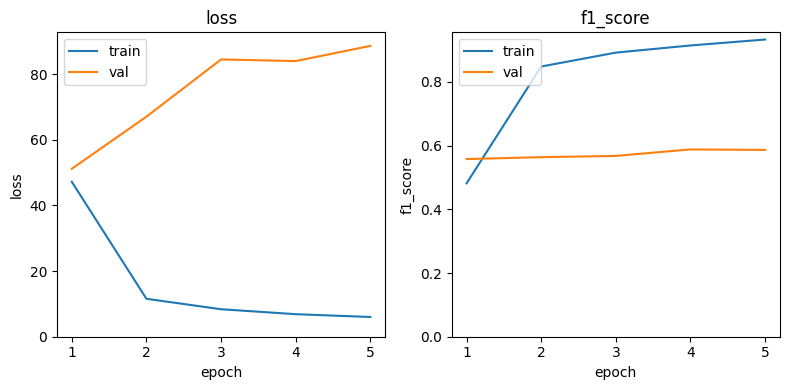

In [58]:
plot_model_history(vgg16_pre_trained_model_history, ["loss", "f1_score"])

using image size (512, 512), no dropout, no augmentation, flatten

In [27]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2334/2335 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - categorical_accuracy: 0.4562 - f1_score: 0.4276 - loss: 95.4653

2026-04-21 13:44:58.964275: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 13:44:59.976656: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 32.52GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 13:45:00.350184: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.33GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 13:45:01.358610: W external/local_xla/xla

2335/2335 ━━━━━━━━━━━━━━━━━━━━ 482s 205ms/step - categorical_accuracy: 0.5463 - f1_score: 0.5164 - loss: 101.6040 - val_categorical_accuracy: 0.6337 - val_f1_score: 0.6109 - val_loss: 112.3538
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 495s 212ms/step - categorical_accuracy: 0.9058 - f1_score: 0.9025 - loss: 20.6045 - val_categorical_accuracy: 0.6472 - val_f1_score: 0.6288 - val_loss: 133.5641
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 471s 202ms/step - categorical_accuracy: 0.9437 - f1_score: 0.9421 - loss: 11.0113 - val_categorical_accuracy: 0.6337 - val_f1_score: 0.6106 - val_loss: 182.8824


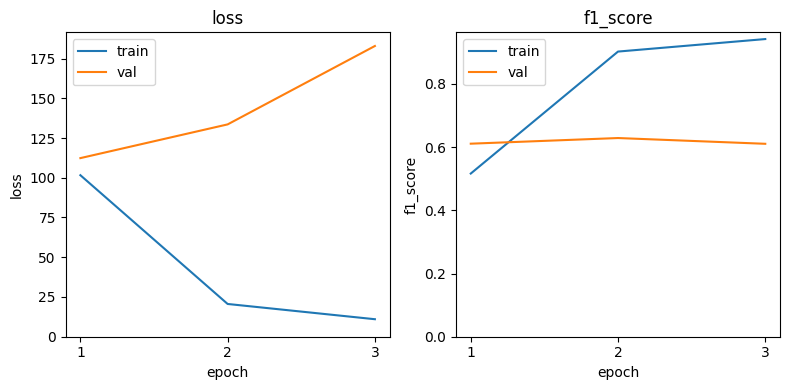

In [50]:
plot_model_history(vgg16_pre_trained_model_history, ["loss", "f1_score"])

## 3. ResNet

Add here a brief explanation of ResNet's ideas and if possible an image of it's architecture

From the ResNet family of models, the one we chose was ResNet152V2, as it was the one with the best performance

In [16]:
resnet152v2_base_model = keras.applications.ResNet152V2(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23
)

# freeze the layers
resnet152v2_base_model.trainable = False

In [17]:
inputs = keras.Input(shape=input_shape)

x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

# apply ResNet preprocessing
# The inputs pixel values are scaled between -1 and 1, sample-wise.
x = keras.applications.resnet_v2.preprocess_input(x)

x = resnet152v2_base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(n_classes, activation="softmax")(x)

resnet152v2_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="resnet152v2_pre_trained")

In [18]:
resnet152v2_pre_trained_model.summary()

Model: "resnet152v2_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate_noise     │ (None, 512, 512, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 16, 16, 2048)   │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,378,775 (222.70 MB)

 Trainable params: 47,127 (184.09 KB)

 Non-trainable params: 58,331,648 (222.52 MB)

using image size (512, 512), 0.2 dropout, moderate noise augmentation, global avg pooling

In [19]:
resnet152v2_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [20]:
resnet152v2_pre_trained_model_history = resnet152v2_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 740s 311ms/step - categorical_accuracy: 0.5931 - f1_score: 0.5625 - loss: 1.4042 - val_categorical_accuracy: 0.7034 - val_f1_score: 0.6621 - val_loss: 1.0167
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 711s 305ms/step - categorical_accuracy: 0.7251 - f1_score: 0.7042 - loss: 0.9130 - val_categorical_accuracy: 0.7274 - val_f1_score: 0.6949 - val_loss: 0.9198
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 712s 305ms/step - categorical_accuracy: 0.7630 - f1_score: 0.7463 - loss: 0.7869 - val_categorical_accuracy: 0.7354 - val_f1_score: 0.7030 - val_loss: 0.8963
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 713s 306ms/step - categorical_accuracy: 0.7791 - f1_score: 0.7656 - loss: 0.7086 - val_categorical_accuracy: 0.7569 - val_f1_score: 0.7346 - val_loss: 0.8321
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 708s 303ms/step - categorical_accuracy: 0.7937 - f1_score: 0.7808 - loss: 0.6614 - val_categorical_accuracy: 0.7569 - val_f1_score: 0.7352 - val_loss: 0.8144


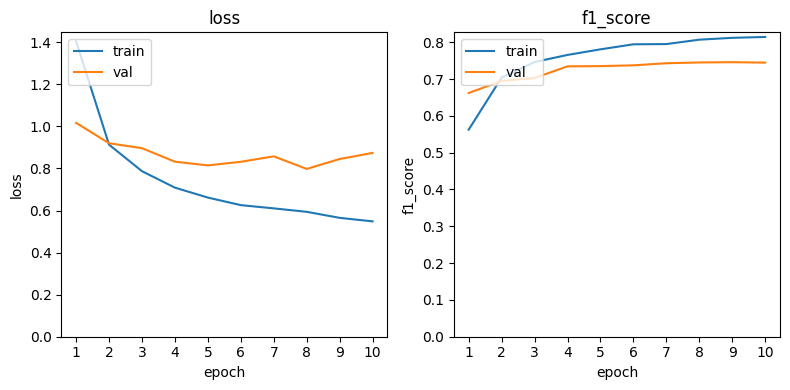

In [21]:
plot_model_history(resnet152v2_pre_trained_model_history, ["loss", "f1_score"])

## 4. EfficientNet

write a bit about efficient net

we will use the biggest EfficientNet model, EfficientNetV2L, which is the model with the best performance

In [5]:
efficient_net_v2l_base_model = keras.applications.EfficientNetV2L(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23
)

# freeze the layers
efficient_net_v2l_base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=input_shape)

x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

x = efficient_net_v2l_base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

efficient_net_v2l_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="efficient_net_v2l_pre_trained")

In [7]:
efficient_net_v2l_pre_trained_model.summary()

Model: "efficient_net_v2l_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate_noise     │ (None, 512, 512, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 16, 16, 1280)   │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,776,311 (449.28 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 117,746,848 (449.17 MB)

using image size (512, 512), 0.2 dropout, moderate noise augmentation, global avg pooling

In [8]:
efficient_net_v2l_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [9]:
efficient_net_v2l_pre_trained_model_history = efficient_net_v2l_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


I0000 00:00:1776812751.538353  186555 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-22 00:05:53.392922: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.67GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - categorical_accuracy: 0.4243 - f1_score: 0.3704 - loss: 1.9700

2026-04-22 00:22:44.639804: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.61GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-22 00:26:09.581548: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.65GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1259s 523ms/step - categorical_accuracy: 0.5292 - f1_score: 0.4944 - loss: 1.6214 - val_categorical_accuracy: 0.6178 - val_f1_score: 0.5840 - val_loss: 1.2943
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1254s 537ms/step - categorical_accuracy: 0.6694 - f1_score: 0.6503 - loss: 1.1447 - val_categorical_accuracy: 0.6688 - val_f1_score: 0.6428 - val_loss: 1.1359
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1195s 512ms/step - categorical_accuracy: 0.6950 - f1_score: 0.6762 - loss: 1.0130 - val_categorical_accuracy: 0.6788 - val_f1_score: 0.6559 - val_loss: 1.0886
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1204s 516ms/step - categorical_accuracy: 0.7200 - f1_score: 0.7042 - loss: 0.9398 - val_categorical_accuracy: 0.6888 - val_f1_score: 0.6660 - val_loss: 1.0359
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1170s 502ms/step - categorical_accuracy: 0.7347 - f1_score: 0.7225 - loss: 0.8977 - val_categorical_accuracy: 0.7054 - val_f1_score: 0.6810 - val_loss: 1.0068
Epoch 

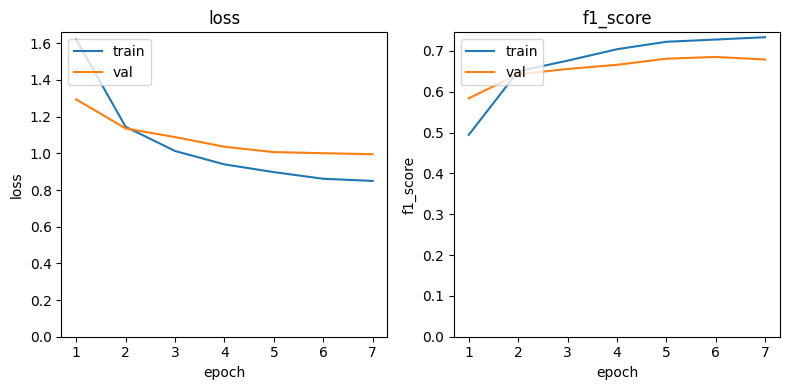

In [11]:
plot_model_history(efficient_net_v2l_pre_trained_model_history, ["loss", "f1_score"])

## 5. ConvNeXt

we will try ConvNeXtXLarge, as it is the model with the best performance

In [ ]:
convnext_x_large_base_model = keras.applications.ConvNeXtXLarge(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23
)

# freeze the layers
convnext_x_large_base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=input_shape)

x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

# apply ResNet preprocessing
# The inputs pixel values are scaled between -1 and 1, sample-wise.
x = keras.applications.convnext.preprocess_input(x)

x = convnext_x_large_base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(n_classes, activation="softmax")(x)

convnext_large_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="convnext_large_pre_trained")

In [ ]:
convnext_large_pre_trained_model.summary()

Model: "efficient_net_v2l_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate_noise     │ (None, 512, 512, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 16, 16, 1280)   │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,776,311 (449.28 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 117,746,848 (449.17 MB)

using image size (512, 512), 0.2 dropout, moderate noise augmentation, global avg pooling

In [ ]:
convnext_large_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [ ]:
convnext_large_pre_trained_model_history = convnext_large_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


I0000 00:00:1776810885.900939  177456 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-21 23:34:47.858346: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.67GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - categorical_accuracy: 0.4332 - f1_score: 0.3861 - loss: 1.9895

2026-04-21 23:51:37.003127: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.61GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 23:54:56.310019: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.65GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1244s 519ms/step - categorical_accuracy: 0.5315 - f1_score: 0.4986 - loss: 1.6342 - val_categorical_accuracy: 0.6228 - val_f1_score: 0.5887 - val_loss: 1.2673
Epoch 2/10
 842/2333 ━━━━━━━━━━━━━━━━━━━━ 10:48 435ms/step - categorical_accuracy: 0.6472 - f1_score: 0.6152 - loss: 1.2196

KeyboardInterrupt: 

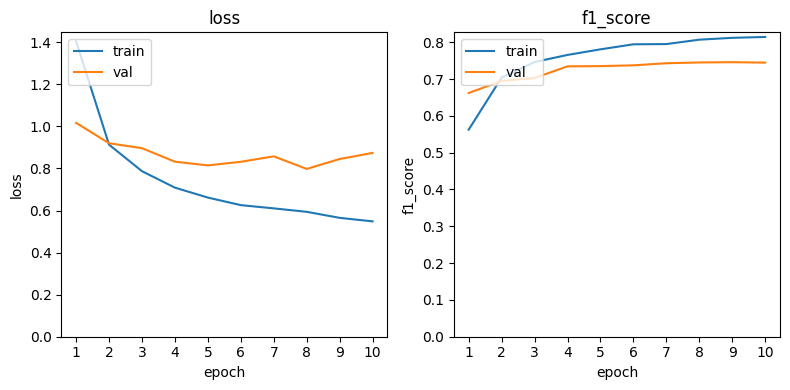

In [ ]:
plot_model_history(convnext_large_pre_trained_model, ["loss", "f1_score"])

## 6. Comparing fine-tuning a smaller model with not fine-tuning a large model or fine-tuning just the last subset of layers

### 6.1. Fully fine-tuning a smaller model

we'll fully fine-tune a smaller version of efficient net

In [ ]:
efficient_net_v2s_base_model = keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    include_preprocessing=True, # EfficientNet already includes preprocessing
    input_shape=input_shape,
    classes=23
)

# freeze the layers
efficient_net_v2s_base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=input_shape)

x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

x = efficient_net_v2s_base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

efficient_net_v2s_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="efficient_net_v2s_pre_trained")

In [ ]:
efficient_net_v2s_pre_trained_model.summary()

Model: "efficient_net_v2l_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate_noise     │ (None, 512, 512, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 16, 16, 1280)   │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,776,311 (449.28 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 117,746,848 (449.17 MB)

using image size (512, 512), 0.2 dropout, moderate noise augmentation, global avg pooling

In [ ]:
efficient_net_v2s_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [ ]:
efficient_net_v2s_pre_trained_model_history = efficient_net_v2s_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


I0000 00:00:1776812751.538353  186555 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-22 00:05:53.392922: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.67GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - categorical_accuracy: 0.4243 - f1_score: 0.3704 - loss: 1.9700

2026-04-22 00:22:44.639804: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.61GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-22 00:26:09.581548: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.65GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1259s 523ms/step - categorical_accuracy: 0.5292 - f1_score: 0.4944 - loss: 1.6214 - val_categorical_accuracy: 0.6178 - val_f1_score: 0.5840 - val_loss: 1.2943
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1254s 537ms/step - categorical_accuracy: 0.6694 - f1_score: 0.6503 - loss: 1.1447 - val_categorical_accuracy: 0.6688 - val_f1_score: 0.6428 - val_loss: 1.1359
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1195s 512ms/step - categorical_accuracy: 0.6950 - f1_score: 0.6762 - loss: 1.0130 - val_categorical_accuracy: 0.6788 - val_f1_score: 0.6559 - val_loss: 1.0886
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1204s 516ms/step - categorical_accuracy: 0.7200 - f1_score: 0.7042 - loss: 0.9398 - val_categorical_accuracy: 0.6888 - val_f1_score: 0.6660 - val_loss: 1.0359
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1170s 502ms/step - categorical_accuracy: 0.7347 - f1_score: 0.7225 - loss: 0.8977 - val_categorical_accuracy: 0.7054 - val_f1_score: 0.6810 - val_loss: 1.0068
Epoch 

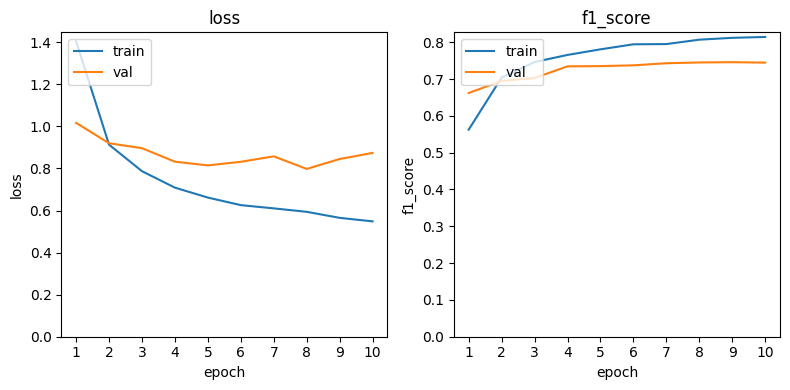

In [ ]:
plot_model_history(efficient_net_v2s_pre_trained_model, ["loss", "f1_score"])

Now apply the fine-tuning, using a lower learning rate and SGD to save memory so that we can fit larger models

after this, try to fine tune the model with adam, just to see if it fits, no need to run full fine-tuning

### 6.2. Fine-tuning just the final layers of the large model

## 7. Final Model and Evaluation